In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [8]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [9]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [10]:
C = torch.randn((27, 3))

In [11]:
emb = C[Xtr]
emb.shape

torch.Size([182625, 3, 3])

In [12]:
W1 = torch.randn((9, 100))
b1 = torch.randn(100)

In [13]:
h = torch.tanh(emb.view(-1, 9) @ W1 + b1)

In [14]:
h

tensor([[-0.3444, -1.0000,  0.2663,  ..., -1.0000, -0.9954,  1.0000],
        [ 0.6179, -0.1278, -0.9930,  ..., -1.0000, -0.9848,  0.9978],
        [-0.9479, -0.9993, -0.9706,  ..., -0.9998,  0.9688,  0.9780],
        ...,
        [ 0.4558, -0.9981,  0.7726,  ...,  1.0000,  0.9964,  0.9832],
        [ 0.9950, -0.9999,  1.0000,  ..., -0.7688, -0.9778,  1.0000],
        [-0.3628, -0.9934, -0.9996,  ..., -0.5059, -0.9834,  0.9999]])

In [15]:
h.shape

torch.Size([182625, 100])

In [16]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [17]:
logits = h @ W2 + b2

In [18]:
# ------------ now made respectable :) ---------------

In [131]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [160]:
length_of_embedding = 40
length_of_first_layer = block_size * length_of_embedding
length_of_hidden_layer = 200
g = torch.Generator().manual_seed(676767676767)
C = torch.randn((27, length_of_embedding), generator=g)
W1 = torch.randn((length_of_first_layer, length_of_hidden_layer), generator=g)
b1 = torch.randn(length_of_hidden_layer, generator=g)
W2 = torch.randn((length_of_hidden_layer, 27), generator=g)  * 0.01
b2 = torch.randn(27, generator=g)  * 0.0001
parameters = [C, W1, b1, W2, b2]

In [161]:
sum(p.nelement() for p in parameters)

30707

In [162]:
for p in parameters:
  p.requires_grad = True

In [163]:
lre = torch.linspace(-3, 0, 10000)
lrs = 10**lre

In [164]:
lri = []
lossi = []
stepi = []

In [165]:
for i in range(200000):

    # minimatch construct
    ix = torch.randint(0, Xtr.shape[0], (64, ))

    # forward pass
    emb = C[Xtr[ix]] # (64, 3, 40)
    h = torch.tanh(emb.view(-1, length_of_first_layer) @ W1 + b1) # (64, 200)
    logits = h @ W2 + b2 # (64, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) 
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.5 if i < 100000 else 0.1
    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(i)
    # lri.append(lre[i])
    lossi.append(loss.log10().item())

3.2996256351470947
3.0651886463165283
3.098004102706909
3.1517951488494873
2.8082034587860107
3.27851939201355
2.6509268283843994
2.5479774475097656
3.1116750240325928
3.9989407062530518
3.083322763442993
3.0996086597442627
2.9905519485473633
2.625913143157959
2.9978251457214355
2.749419689178467
2.73911714553833
2.7956573963165283
3.344625949859619
2.70928955078125
2.73776912689209
3.1499338150024414
3.1553823947906494
2.5814995765686035
2.395233392715454
2.7544851303100586
2.7910826206207275
2.483591318130493
2.3152084350585938
2.744025468826294
3.044616222381592
3.041145086288452
2.873918294906616
2.813326358795166
2.6219406127929688
3.2076077461242676
3.0879807472229004
2.8267734050750732
2.323655366897583
2.87093186378479
2.719651937484741
2.6688315868377686
2.7652032375335693
2.8155112266540527
2.847726345062256
2.225706100463867
3.0986030101776123
2.899061441421509
2.521873712539673
2.911972999572754
2.724275588989258
2.9669833183288574
2.69705867767334
3.088271379470825
3.19127

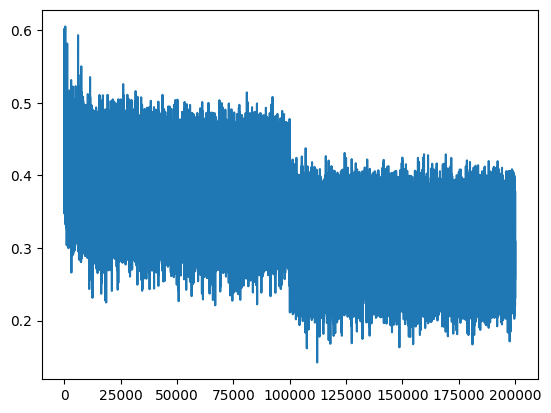

In [172]:
plt.plot(stepi, lossi)

In [173]:
# Training Loss
emb = C[Xtr] # (64, 3, 40)
h = torch.tanh(emb.view(-1, length_of_first_layer) @ W1 + b1) # (64, 200)
logits = h @ W2 + b2 # (64, 27)
loss = F.cross_entropy(logits, Ytr) 
loss

tensor(2.0441, grad_fn=<NllLossBackward0>)

In [174]:
# Dev Loss
emb = C[Xdev] # (64, 3, 40)
h = torch.tanh(emb.view(-1, length_of_first_layer) @ W1 + b1) # (64, 200)
logits = h @ W2 + b2 # (64, 27)
loss = F.cross_entropy(logits, Ydev) 
loss

tensor(2.1605, grad_fn=<NllLossBackward0>)

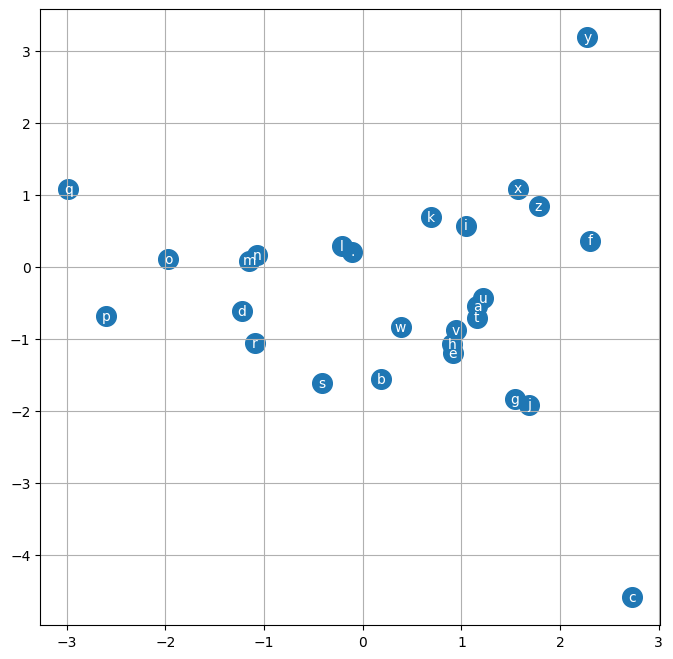

In [175]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [176]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 40])

In [177]:

# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carla.
fati.
harlin.
miliana.
casparsha.
jazon.
nadeliah.
jareei.
nellara.
chaily.
kaleigh.
ham.
joce.
quint.
shoilea.
jadique.
jermaijarynn.
jace.
cinsleigh.
edi.


In [178]:
# Final Loss
emb = C[Xte] # (64, 3, 40)
h = torch.tanh(emb.view(-1, length_of_first_layer) @ W1 + b1) # (64, 200)
logits = h @ W2 + b2 # (64, 27)
loss = F.cross_entropy(logits, Yte) 
loss

tensor(2.1622, grad_fn=<NllLossBackward0>)